# Composition and Mixing Variable Correlations

This notebook checks dependence among the variables used by the Bayesian composition and mixing models. It uses the same data-loading and standardisation choices as `bayesian_socio_geo_demo_regression.ipynb`, but does not fit Bambi models.

The main outputs are:

- numeric-to-numeric Spearman/Pearson correlations
- categorical-to-categorical association using Cramer's V
- categorical-to-numeric association using eta-squared
- predictor association with the binary `candidate` outcome

In [1]:
from __future__ import annotations

from collections.abc import Iterable, Sequence
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml
from scipy.stats import chi2_contingency

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "utils").exists() and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "utils").exists():
    raise RuntimeError("Run this notebook from inside the scotland repository.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

SSE_OUTPUT_DIR = PROJECT_ROOT / "sse_detection" / "results" / "sse_outputs"
RESULT_DIR = PROJECT_ROOT / "sse_detection" / "results" / "bayesian_socio_geo_demo"
CORR_DIR = RESULT_DIR / "correlation_checks"
CORR_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 123
CLUSTER_ID_COL = "cluster_id"
MIXING_GROUP_VARS = ("policy_period", "clade")
COMP_GROUP_VARS = MIXING_GROUP_VARS

pd.set_option("display.max_columns", 140)
pd.set_option("display.width", 180)
sns.set_theme(style="whitegrid", context="notebook")

## Model Variable Definitions

These mirror the regression notebook. The composition models use sequence-level demographic/geographic variables. The mixing models use node-level entropy/mixing variables. Both families include the same window surveillance adjusters; the expanded versions also include datazone context adjusters.

In [2]:
HIGH_PRIORITY_CANDIDATE_TIERS = frozenset(
    {"high_priority_both_axes", "high_priority_burst", "high_priority_burden"}
)

DEFAULT_MIXING_FEATURES = [
    "sex_entropy_z",
    "age_entropy_z",
    "simd_entropy_z",
    "datazone_entropy_z",
    "local_authority_entropy_z",
    "urban_rural_entropy_z",
    "health_board_entropy_z",
    "vaccination_entropy_z",
]

OBSERVED_MIXING_FEATURES = [
    "sex_entropy_obs",
    "age_entropy_obs",
    "simd_entropy_obs",
    "datazone_entropy_obs",
    "local_authority_entropy_obs",
    "urban_rural_entropy_obs",
    "health_board_entropy_obs",
    "vaccination_entropy_obs",
]
OBSERVED_MIXING_FEATURES_X10 = [
    f"{feature}_x10" for feature in OBSERVED_MIXING_FEATURES
    ]

NULL_MIXING_FEATURES = DEFAULT_MIXING_FEATURES
OBSERVED_MIXING_FEATURES = OBSERVED_MIXING_FEATURES_X10

COMPOSITION_SPECS = [
    {"name": "sex", "column": "sex", "reference": "Male", "label": "Sex"},
    {"name": "age_band", "column": "age_band", "reference": "20-24", "label": "Age band"},
    {"name": "simd_quintile", "column": "dz_simd_quintile", "reference": 1, "label": "SIMD quintile"},
    {
        "name": "urban_rural_class",
        "column": "dz_urban_rural_class",
        "reference": "Large Urban Areas",
        "label": "Urban/rural class",
    },
    {
        "name": "health_board",
        "column": "dz_health_board",
        "reference": "Greater Glasgow and Clyde",
        "label": "Health board",
    },
]

COMPOSITION_FEATURES = {spec["column"]: spec["reference"] for spec in COMPOSITION_SPECS}
COMPOSITION_PREDICTORS = list(COMPOSITION_FEATURES)

STANDARDISE_SPECS = {
    "wn_prop_sequenced_z": "wn_prop_sequenced",
    "wn_positive_tests_log1p_z": "log1p_wn_positive_tests",
    "dz_cum_prop_sequenced_z": "dz_cum_prop_sequenced",
    "dz_cum_incidence_per_capita_z": "dz_cum_incidence_per_capita",
    "dz_7d_test_positivity_z": "dz_7d_test_positivity",
    "dz_cum_positive_tests_log1p_z": "log1p_dz_cum_positive_tests",
    "dz_cum_prop_vaccinated_z": "dz_cum_prop_vaccinated",
}

WINDOW_CONTEXT_ADJUSTERS = [
    "wn_prop_sequenced_z",
    "wn_positive_tests_log1p_z",
]

DATAZONE_CONTEXT_ADJUSTERS = [
    "dz_cum_prop_sequenced_z",
    "dz_cum_incidence_per_capita_z",
    "dz_7d_test_positivity_z",
    "dz_cum_positive_tests_log1p_z",
]

NULL_MIXING_PREDICTORS = NULL_MIXING_FEATURES + WINDOW_CONTEXT_ADJUSTERS
OBSERVED_MIXING_PREDICTORS = OBSERVED_MIXING_FEATURES + WINDOW_CONTEXT_ADJUSTERS

MODEL_SPECS = {
    "composition_primary": {
        "level": "sequence",
        "predictors": COMPOSITION_PREDICTORS + WINDOW_CONTEXT_ADJUSTERS,
        "group_vars": COMP_GROUP_VARS,
    },
    "composition_expanded": {
        "level": "sequence",
        "predictors": COMPOSITION_PREDICTORS + WINDOW_CONTEXT_ADJUSTERS + DATAZONE_CONTEXT_ADJUSTERS,
        "group_vars": COMP_GROUP_VARS,
    },
    "mixing_null_primary": {
        "level": "node",
        "predictors": NULL_MIXING_PREDICTORS,
        "group_vars": MIXING_GROUP_VARS,
    },
    "mixing_null_expanded": {
        "level": "node",
        "predictors": NULL_MIXING_PREDICTORS + DATAZONE_CONTEXT_ADJUSTERS,
        "group_vars": MIXING_GROUP_VARS,
    },
    "mixing_observed_primary": {
        "level": "node",
        "predictors": OBSERVED_MIXING_PREDICTORS,
        "group_vars": MIXING_GROUP_VARS,
    },
    "mixing_observed_expanded": {
        "level": "node",
        "predictors": OBSERVED_MIXING_PREDICTORS + DATAZONE_CONTEXT_ADJUSTERS,
        "group_vars": MIXING_GROUP_VARS,
    },
}

pd.DataFrame(
    [
        {
            "model": name,
            "level": spec["level"],
            "n_predictors": len(spec["predictors"]),
            "predictors": ", ".join(spec["predictors"]),
            "group_vars": ", ".join(spec["group_vars"]),
        }
        for name, spec in MODEL_SPECS.items()
    ]
)

,model,level,n_predictors,predictors,group_vars
0,composition_primary,sequence,7,"sex, age_band, dz_simd_quintile, dz_urban_rura...","policy_period, clade"
1,composition_expanded,sequence,11,"sex, age_band, dz_simd_quintile, dz_urban_rura...","policy_period, clade"
2,mixing_null_primary,node,10,"sex_entropy_z, age_entropy_z, simd_entropy_z, ...","policy_period, clade"
3,mixing_null_expanded,node,14,"sex_entropy_z, age_entropy_z, simd_entropy_z, ...","policy_period, clade"
4,mixing_observed_primary,node,10,"sex_entropy_obs_x10, age_entropy_obs_x10, simd...","policy_period, clade"
5,mixing_observed_expanded,node,14,"sex_entropy_obs_x10, age_entropy_obs_x10, simd...","policy_period, clade"


## Load and Recreate Analysis Frames

The node-level `candidate` outcome follows the main SSE pipeline. The sequence-level composition data inherits the candidate label from its cluster.

In [3]:
PERIOD_CODES = [
    "E0", "L1", "P1", "P2", "P3", "T1", "F5", "L2",
    "SL", "L3", "L21", "L0", "NN", "OM", "FE", "PR",
]
POLICY_PERIODS = pd.DataFrame(
    {
        "period_code": PERIOD_CODES,
        "start_date": pd.to_datetime(
            [
                "2020-03-01", "2020-03-24", "2020-05-29", "2020-06-19",
                "2020-07-10", "2020-10-02", "2020-11-02", "2021-01-05",
                "2021-04-02", "2021-04-26", "2021-05-17", "2021-07-19",
                "2021-08-09", "2021-11-29", "2022-01-24", "2022-04-18",
            ]
        ).normalize(),
        "end_date": pd.to_datetime(
            [
                "2020-03-23", "2020-05-28", "2020-06-18", "2020-07-09",
                "2020-10-01", "2020-11-01", "2021-01-04", "2021-04-01",
                "2021-04-25", "2021-05-16", "2021-07-18", "2021-08-08",
                "2021-11-28", "2022-01-23", "2022-04-17", "2023-05-05",
            ]
        ).normalize(),
        "intensity": [15, 100, 72, 52, 30, 55, 65, 95, 65, 55, 38, 20, 10, 42, 15, 3],
    }
)
POLICY_PERIODS["period_code"] = pd.Categorical(POLICY_PERIODS["period_code"], categories=PERIOD_CODES, ordered=True)


def attach_policy_period(df: pd.DataFrame, date_col: str = "collection_date") -> pd.DataFrame:
    out = df.copy()
    dates = pd.to_datetime(out[date_col]).dt.normalize()
    codes = np.full(len(out), None, dtype=object)
    for _, row in POLICY_PERIODS.iterrows():
        mask = dates.between(row["start_date"], row["end_date"], inclusive="both")
        codes[mask.to_numpy()] = str(row["period_code"])
    out["policy_period"] = pd.Categorical(codes, categories=PERIOD_CODES, ordered=True)
    out["policy_intensity"] = out["policy_period"].map(
        dict(zip(POLICY_PERIODS["period_code"].astype(str), POLICY_PERIODS["intensity"]))
    )
    return out


def select_window_stride(windows: Iterable[int], stride: int = 2, offset: int = 0) -> list[int]:
    sorted_windows = sorted(pd.Series(list(windows)).dropna().astype(int).unique())
    return sorted_windows[offset::stride]


def apply_window_stride(df: pd.DataFrame, stride: int = 2, offset: int = 0) -> pd.DataFrame:
    retained = select_window_stride(df["window_idx"], stride=stride, offset=offset)
    old_to_new = {old: new + 1 for new, old in enumerate(retained)}
    out = df.loc[df["window_idx"].isin(retained)].copy()
    out["window_idx"] = out["window_idx"].map(old_to_new)
    if "window_id" in out.columns:
        out["window_id"] = out["window_idx"].apply(lambda x: f"W{x:03d}")
    return out.reset_index(drop=True)


def config_paths() -> dict[str, Path]:
    with open(PROJECT_ROOT / "config.yaml") as f:
        cfg = yaml.safe_load(f)
    processed = cfg["data"]["processed"]
    return {key: PROJECT_ROOT / value for key, value in processed.items()}


def apply_weighted_simd_quintile(df: pd.DataFrame) -> pd.DataFrame:
    if "dz_simd_quintile" not in df.columns or "datazone" not in df.columns:
        return df

    paths = config_paths()
    lookup = pd.read_parquet(
        paths["geography"],
        columns=["dz_population", "dz_simd_rank", "dz_simd_quintile"],
    ).reset_index()
    valid = lookup["dz_population"].notna() & lookup["dz_simd_rank"].notna()
    ordered = lookup.loc[valid].sort_values("dz_simd_rank", ascending=True).copy()
    cum_prop = ordered["dz_population"].cumsum() / ordered["dz_population"].sum()
    ordered["dz_simd_quintile_weighted"] = np.ceil(cum_prop * 5).astype(int).clip(1, 5)
    mapping = ordered.set_index("datazone")["dz_simd_quintile_weighted"]

    out = df.copy()
    out["dz_simd_quintile"] = out["datazone"].map(mapping).fillna(out["dz_simd_quintile"])
    return out


def load_sequence_data_light(columns: Sequence[str]) -> pd.DataFrame:
    paths = config_paths()
    need = set(columns) | {"sequence_id", "collection_date", "pango_lineage", "resolution", "nextclade_qc", "window_idx", "window_id"}
    if "dz_simd_quintile" in need:
        need.add("datazone")
    df = pd.read_parquet(paths["analysis_dataset"], columns=list(need))
    df = df.loc[df["resolution"].eq(0.3) & df["nextclade_qc"].eq("good")].copy()
    df = apply_window_stride(df, stride=2)
    df = apply_weighted_simd_quintile(df)
    df = attach_policy_period(df, "collection_date")
    for col, value in {"is_vaccinated": 0.0, "days_since_vaccination": -1, "vacc_booster": 0, "who_voc": "Other/Non-VOC"}.items():
        if col in df.columns:
            df[col] = df[col].fillna(value)
    return df.reset_index(drop=True)


def load_sse_outputs_light(output_dir: Path) -> tuple[pd.DataFrame, pd.DataFrame]:
    cluster_table = pd.read_parquet(output_dir / "cluster_table.parquet")
    edge_table = pd.read_parquet(output_dir / "edge_table.parquet")
    for col in ["wn_start_date", "wn_mid_date", "wn_end_date", "first_collection_date", "last_collection_date"]:
        if col in cluster_table.columns:
            cluster_table[col] = pd.to_datetime(cluster_table[col], errors="coerce")
    if "who_voc" in cluster_table.columns and "who_voc_plot" not in cluster_table.columns:
        cluster_table["who_voc_plot"] = cluster_table["who_voc"].fillna("None")
    return cluster_table, edge_table


def add_observed_mixing_entropy_scales_light(
    cluster_stats: pd.DataFrame,
    *,
    cluster_col: str = "cluster_id",
    multiplier: float = 10,
) -> pd.DataFrame:
    out = cluster_stats.copy()
    for feature in [
        "sex_entropy_obs", "age_entropy_obs", "simd_entropy_obs", "datazone_entropy_obs",
        "local_authority_entropy_obs", "urban_rural_entropy_obs", "health_board_entropy_obs",
        "vaccination_entropy_obs",
    ]:
        if feature in out.columns:
            out[f"{feature}_x10"] = out[feature].astype(float) * multiplier
    return out


def add_standardised_adjusters(data: pd.DataFrame) -> pd.DataFrame:
    """Add standardised surveillance/context adjusters used by the regression notebook."""
    out = add_observed_mixing_entropy_scales_light(data)
    if "wn_positive_tests" in out.columns:
        out["log1p_wn_positive_tests"] = np.log1p(out["wn_positive_tests"])
    if "dz_cum_positive_tests" in out.columns:
        out["log1p_dz_cum_positive_tests"] = np.log1p(out["dz_cum_positive_tests"])

    for target, source in STANDARDISE_SPECS.items():
        if source not in out.columns:
            continue
        values = out[source].astype(float)
        sd = values.std(skipna=True)
        out[target] = np.nan if pd.isna(sd) or sd == 0 else (values - values.mean(skipna=True)) / sd
    return out


def complete_case_frame(
    df: pd.DataFrame,
    *,
    outcome: str,
    predictors: Sequence[str],
    group_vars: Sequence[str],
) -> pd.DataFrame:
    """Return the outcome/predictor/group columns used by one model, dropping incomplete rows."""
    cols = [outcome, *predictors, *group_vars]
    cols = list(dict.fromkeys(cols))
    missing = [col for col in cols if col not in df.columns]
    if missing:
        raise KeyError(f"Missing columns: {missing}")
    return df.loc[:, cols].dropna().copy()


def raw_source_for_predictor(col: str) -> str:
    source = STANDARDISE_SPECS.get(col, col)
    if source == "log1p_wn_positive_tests":
        return "wn_positive_tests"
    if source == "log1p_dz_cum_positive_tests":
        return "dz_cum_positive_tests"
    return source


raw_predictor_sources = {
    raw_source_for_predictor(col)
    for col in [*COMPOSITION_PREDICTORS, *WINDOW_CONTEXT_ADJUSTERS, *DATAZONE_CONTEXT_ADJUSTERS]
}
raw_group_sources = {col for col in COMP_GROUP_VARS if col != "policy_period"}
required_sequence_columns = sorted(
    raw_predictor_sources
    | raw_group_sources
    | {CLUSTER_ID_COL}
    | {"wn_positive_tests", "dz_cum_positive_tests", "collection_date", "window_idx", "window_id", "datazone"}
)

cluster_table, edge_table = load_sse_outputs_light(SSE_OUTPUT_DIR)
cluster_data = add_standardised_adjusters(cluster_table.copy())
sequence_data = add_standardised_adjusters(load_sequence_data_light(required_sequence_columns))

cluster_data["candidate"] = cluster_data["candidate_tier"].isin(HIGH_PRIORITY_CANDIDATE_TIERS)

candidate_sizes = cluster_data.loc[cluster_data["candidate"], "cluster_size"].dropna()
if candidate_sizes.empty:
    raise ValueError("No high-priority candidate nodes were found.")

min_candidate_size = int(candidate_sizes.min())
eligible_nodes = cluster_data.loc[cluster_data["cluster_size"].ge(min_candidate_size)].copy()
eligible_sequence_data = sequence_data.merge(
    eligible_nodes[[CLUSTER_ID_COL, "candidate"]],
    on=CLUSTER_ID_COL,
    how="inner",
)

base_summary = pd.DataFrame(
    [
        {
            "dataset": "eligible_nodes",
            "rows": len(eligible_nodes),
            "candidate_rate": eligible_nodes["candidate"].mean(),
            "candidates": int(eligible_nodes["candidate"].sum()),
        },
        {
            "dataset": "eligible_sequence_data",
            "rows": len(eligible_sequence_data),
            "candidate_rate": eligible_sequence_data["candidate"].mean(),
            "candidates": int(eligible_sequence_data["candidate"].sum()),
        },
    ]
)
base_summary

,dataset,rows,candidate_rate,candidates
0,eligible_nodes,13059,0.047017,614
1,eligible_sequence_data,264139,0.253049,66840


In [4]:
analysis_frames = {}
for model_name, spec in MODEL_SPECS.items():
    source = eligible_sequence_data if spec["level"] == "sequence" else eligible_nodes
    analysis_frames[model_name] = complete_case_frame(
        source,
        outcome="candidate",
        predictors=spec["predictors"],
        group_vars=spec["group_vars"],
    )

frame_summary = pd.DataFrame(
    [
        {
            "model": name,
            "level": MODEL_SPECS[name]["level"],
            "rows": len(frame),
            "candidate_rate": frame["candidate"].mean(),
            "n_predictors": len(MODEL_SPECS[name]["predictors"]),
        }
        for name, frame in analysis_frames.items()
    ]
)
frame_summary.to_csv(CORR_DIR / "frame_summary.csv", index=False)
frame_summary

,model,level,rows,candidate_rate,n_predictors
0,composition_primary,sequence,264139,0.253049,7
1,composition_expanded,sequence,264119,0.253068,11
2,mixing_null_primary,node,12525,0.048224,10
3,mixing_null_expanded,node,12525,0.048224,14
4,mixing_observed_primary,node,13059,0.047017,10
5,mixing_observed_expanded,node,13059,0.047017,14


## Association Helpers

Interpretation guide:

- Spearman/Pearson correlations near `+1` or `-1` indicate strong monotonic/linear dependence among numeric predictors.
- Cramer's V ranges from `0` to `1` for categorical-categorical association.
- Eta-squared ranges from `0` to `1` and measures how much numeric variation is explained by categories.
- Candidate correlations are descriptive only; they do not replace the Bayesian model.

In [5]:
def numeric_predictors(frame: pd.DataFrame, predictors: Sequence[str]) -> list[str]:
    return [col for col in predictors if col in frame.columns and pd.api.types.is_numeric_dtype(frame[col])]


def categorical_predictors(frame: pd.DataFrame, predictors: Sequence[str]) -> list[str]:
    return [col for col in predictors if col in frame.columns and not pd.api.types.is_numeric_dtype(frame[col])]


def correlation_matrix(frame: pd.DataFrame, columns: Sequence[str], method: str = "spearman") -> pd.DataFrame:
    cols = [col for col in columns if col in frame.columns]
    if len(cols) < 2:
        return pd.DataFrame(index=cols, columns=cols, dtype=float)
    return frame.loc[:, cols].corr(method=method) # type: ignore


def top_abs_correlations(corr: pd.DataFrame, n: int = 20) -> pd.DataFrame:
    if corr.empty:
        return pd.DataFrame(columns=["var1", "var2", "correlation", "abs_correlation"])
    mask = np.triu(np.ones(corr.shape, dtype=bool), k=1)
    pairs = corr.where(mask).stack().reset_index()
    pairs.columns = ["var1", "var2", "correlation"]
    pairs["abs_correlation"] = pairs["correlation"].abs()
    return pairs.sort_values("abs_correlation", ascending=False).head(n).reset_index(drop=True)


def cramers_v(x: pd.Series, y: pd.Series) -> float:
    data = pd.crosstab(x, y)
    if data.shape[0] < 2 or data.shape[1] < 2:
        return np.nan
    chi2 = chi2_contingency(data, correction=False)[0]
    n = data.to_numpy().sum()
    phi2 = chi2 / n
    r, k = data.shape
    # Bias-corrected Cramer's V.
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    denom = min(kcorr - 1, rcorr - 1)
    return np.sqrt(phi2corr / denom) if denom > 0 else np.nan


def cramers_v_matrix(frame: pd.DataFrame, columns: Sequence[str]) -> pd.DataFrame:
    cols = [col for col in columns if col in frame.columns]
    out = pd.DataFrame(np.eye(len(cols)), index=cols, columns=cols, dtype=float)
    for i, col1 in enumerate(cols):
        for col2 in cols[i + 1 :]:
            val = cramers_v(frame[col1], frame[col2])
            out.loc[col1, col2] = val
            out.loc[col2, col1] = val
    return out


def eta_squared(categories: pd.Series, values: pd.Series) -> float:
    valid = categories.notna() & values.notna()
    categories = categories.loc[valid]
    values = values.loc[valid].astype(float)
    if values.empty or categories.nunique() < 2:
        return np.nan
    grand_mean = values.mean()
    ss_between = values.groupby(categories).agg(lambda x: len(x) * (x.mean() - grand_mean) ** 2).sum()
    ss_total = ((values - grand_mean) ** 2).sum()
    return float(ss_between / ss_total) if ss_total > 0 else np.nan


def categorical_numeric_eta(frame: pd.DataFrame, categorical_cols: Sequence[str], numeric_cols: Sequence[str]) -> pd.DataFrame:
    rows = []
    for cat in categorical_cols:
        for num in numeric_cols:
            rows.append({"categorical": cat, "numeric": num, "eta_squared": eta_squared(frame[cat], frame[num])})
    out = pd.DataFrame(rows, columns=["categorical", "numeric", "eta_squared"])
    return out.sort_values("eta_squared", ascending=False).reset_index(drop=True) if not out.empty else out


def candidate_numeric_association(frame: pd.DataFrame, numeric_cols: Sequence[str]) -> pd.DataFrame:
    rows = []
    y = frame["candidate"].astype(int)
    for col in numeric_cols:
        x = frame[col].astype(float)
        rows.append(
            {
                "predictor": col,
                "candidate_correlation": x.corr(y, method="spearman"), # type: ignore
                "candidate_mean": frame.loc[frame["candidate"], col].mean(),
                "non_candidate_mean": frame.loc[~frame["candidate"], col].mean(),
                "mean_difference": frame.loc[frame["candidate"], col].mean() - frame.loc[~frame["candidate"], col].mean(),
            }
        )
    out = pd.DataFrame(rows)
    out["abs_candidate_correlation"] = out["candidate_correlation"].abs()
    return out.sort_values("abs_candidate_correlation", ascending=False).reset_index(drop=True)


def candidate_categorical_association(frame: pd.DataFrame, categorical_cols: Sequence[str]) -> pd.DataFrame:
    rows = []
    for col in categorical_cols:
        rows.append({"predictor": col, "cramers_v_with_candidate": cramers_v(frame[col], frame["candidate"])})
    out = pd.DataFrame(rows, columns=["predictor", "cramers_v_with_candidate"])
    return out.sort_values("cramers_v_with_candidate", ascending=False).reset_index(drop=True) if not out.empty else out


def plot_heatmap(matrix: pd.DataFrame, title: str, *, center: float | None = 0, cmap: str = "vlag", figsize: tuple[int, int] | None = None) -> None:
    if matrix.empty:
        print(f"No matrix to plot for {title}")
        return
    if figsize is None:
        size = max(6, min(14, 0.65 * len(matrix.columns) + 3))
        figsize = (int(size), int(size))
    plt.figure(figsize=figsize)
    sns.heatmap(matrix, annot=True, fmt=".2f", cmap=cmap, center=center, square=True, cbar_kws={"shrink": 0.8})
    plt.title(title)
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

## Run Correlation Checks for All Model Frames

This cell writes tidy CSVs under `sse_detection/results/bayesian_socio_geo_demo/correlation_checks/` and prints the strongest associations for each model frame.

In [6]:
all_outputs = {}

for model_name, frame in analysis_frames.items():
    predictors = MODEL_SPECS[model_name]["predictors"]
    num_cols = numeric_predictors(frame, predictors)
    cat_cols = categorical_predictors(frame, predictors)

    spearman = correlation_matrix(frame, num_cols, method="spearman")
    pearson = correlation_matrix(frame, num_cols, method="pearson")
    numeric_top = top_abs_correlations(spearman, n=25)
    cat_cat = cramers_v_matrix(frame, cat_cols)
    cat_num = categorical_numeric_eta(frame, cat_cols, num_cols)
    y_num = candidate_numeric_association(frame, num_cols)
    y_cat = candidate_categorical_association(frame, cat_cols)

    spearman.to_csv(CORR_DIR / f"{model_name}_numeric_spearman.csv")
    pearson.to_csv(CORR_DIR / f"{model_name}_numeric_pearson.csv")
    numeric_top.to_csv(CORR_DIR / f"{model_name}_top_numeric_correlations.csv", index=False)
    cat_cat.to_csv(CORR_DIR / f"{model_name}_categorical_cramers_v.csv")
    cat_num.to_csv(CORR_DIR / f"{model_name}_categorical_numeric_eta.csv", index=False)
    y_num.to_csv(CORR_DIR / f"{model_name}_candidate_numeric_association.csv", index=False)
    y_cat.to_csv(CORR_DIR / f"{model_name}_candidate_categorical_association.csv", index=False)

    all_outputs[model_name] = {
        "numeric_cols": num_cols,
        "categorical_cols": cat_cols,
        "spearman": spearman,
        "pearson": pearson,
        "numeric_top": numeric_top,
        "cat_cat": cat_cat,
        "cat_num": cat_num,
        "candidate_numeric": y_num,
        "candidate_categorical": y_cat,
    }

    print("=" * 100)
    print(model_name)
    print(f"rows={len(frame):,}; numeric predictors={len(num_cols)}; categorical predictors={len(cat_cols)}")
    print("\nStrongest numeric predictor correlations, Spearman:")
    display(numeric_top.head(10))
    if len(cat_cols) >= 2:
        print("\nStrongest categorical-categorical associations, Cramer's V:")
        display(top_abs_correlations(cat_cat, n=10).rename(columns={"correlation": "cramers_v", "abs_correlation": "abs_cramers_v"}))
    if not cat_num.empty:
        print("\nStrongest categorical-numeric associations, eta-squared:")
        display(cat_num.head(10))
    print("\nCandidate vs numeric predictors:")
    display(y_num.head(10))
    if not y_cat.empty:
        print("\nCandidate vs categorical predictors:")
        display(y_cat.head(10))

composition_primary
rows=264,139; numeric predictors=3; categorical predictors=4

Strongest numeric predictor correlations, Spearman:


,var1,var2,correlation,abs_correlation
0,wn_prop_sequenced_z,wn_positive_tests_log1p_z,-0.659853,0.659853
1,dz_simd_quintile,wn_positive_tests_log1p_z,0.039077,0.039077
2,dz_simd_quintile,wn_prop_sequenced_z,-0.012900,0.012900



Strongest categorical-categorical associations, Cramer's V:


,var1,var2,cramers_v,abs_cramers_v
0,dz_urban_rural_class,dz_health_board,0.399716,0.399716
1,sex,age_band,0.045601,0.045601
2,age_band,dz_urban_rural_class,0.041933,0.041933
3,age_band,dz_health_board,0.026403,0.026403
4,sex,dz_health_board,0.009590,0.009590
5,sex,dz_urban_rural_class,0.002004,0.002004



Strongest categorical-numeric associations, eta-squared:


...

,predictor,candidate_correlation,candidate_mean,non_candidate_mean,mean_difference,abs_candidate_correlation
0,datazone_entropy_obs_x10,0.294216,4.148196,2.318259,1.829937,0.294216
1,age_entropy_obs_x10,0.262506,8.209421,6.013625,2.195796,0.262506
2,simd_entropy_obs_x10,0.240979,9.131500,7.161390,1.970110,0.240979
3,local_authority_entropy_obs_x10,0.235375,5.784516,3.154511,2.630005,0.235375
4,health_board_entropy_obs_x10,0.213604,5.359067,2.918540,2.440527,0.213604
5,urban_rural_entropy_obs_x10,0.188520,6.469002,4.519807,1.949194,0.188520
6,sex_entropy_obs_x10,0.108217,9.576519,8.788628,0.787891,0.108217
7,vaccination_entropy_obs_x10,0.041735,7.153539,6.076039,1.077500,0.041735
8,wn_positive_tests_log1p_z,0.021687,0.048856,-0.067978,0.116834,0.021687
9,wn_prop_sequenced_z,0.001586,0.261240,0.261183,0.000057,0.001586


mixing_observed_expanded
rows=13,059; numeric predictors=14; categorical predictors=0

Strongest numeric predictor correlations, Spearman:


,var1,var2,correlation,abs_correlation
0,dz_cum_incidence_per_capita_z,dz_cum_positive_tests_log1p_z,0.981206,0.981206
1,local_authority_entropy_obs_x10,health_board_entropy_obs_x10,0.896988,0.896988
2,age_entropy_obs_x10,datazone_entropy_obs_x10,0.769361,0.769361
3,simd_entropy_obs_x10,datazone_entropy_obs_x10,0.727630,0.727630
4,dz_cum_incidence_per_capita_z,dz_7d_test_positivity_z,0.724734,0.724734
5,dz_7d_test_positivity_z,dz_cum_positive_tests_log1p_z,0.701959,0.701959
6,datazone_entropy_obs_x10,local_authority_entropy_obs_x10,0.630443,0.630443
7,local_authority_entropy_obs_x10,urban_rural_entropy_obs_x10,0.628209,0.628209
8,urban_rural_entropy_obs_x10,health_board_entropy_obs_x10,0.600666,0.600666
9,age_entropy_obs_x10,simd_entropy_obs_x10,0.569805,0.569805



Candidate vs numeric predictors:


,predictor,candidate_correlation,candidate_mean,non_candidate_mean,mean_difference,abs_candidate_correlation
0,datazone_entropy_obs_x10,0.294216,4.148196,2.318259,1.829937,0.294216
1,age_entropy_obs_x10,0.262506,8.209421,6.013625,2.195796,0.262506
2,simd_entropy_obs_x10,0.240979,9.131500,7.161390,1.970110,0.240979
3,local_authority_entropy_obs_x10,0.235375,5.784516,3.154511,2.630005,0.235375
4,health_board_entropy_obs_x10,0.213604,5.359067,2.918540,2.440527,0.213604
5,urban_rural_entropy_obs_x10,0.188520,6.469002,4.519807,1.949194,0.188520
6,sex_entropy_obs_x10,0.108217,9.576519,8.788628,0.787891,0.108217
7,vaccination_entropy_obs_x10,0.041735,7.153539,6.076039,1.077500,0.041735
8,wn_positive_tests_log1p_z,0.021687,0.048856,-0.067978,0.116834,0.021687
9,dz_cum_prop_sequenced_z,0.010436,0.069942,0.117196,-0.047254,0.010436


## Heatmaps

Change `MODEL_TO_PLOT` to inspect a different model frame. Good starting points are `composition_expanded`, `mixing_null_expanded`, and `mixing_observed_expanded`.

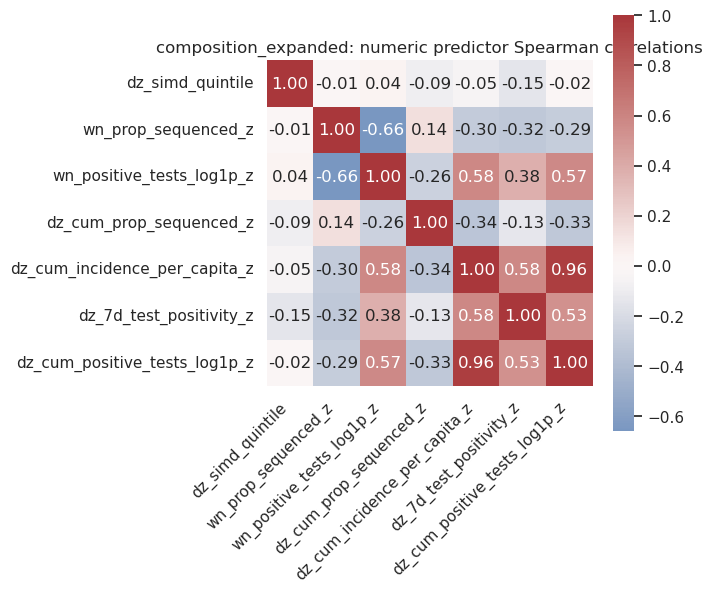

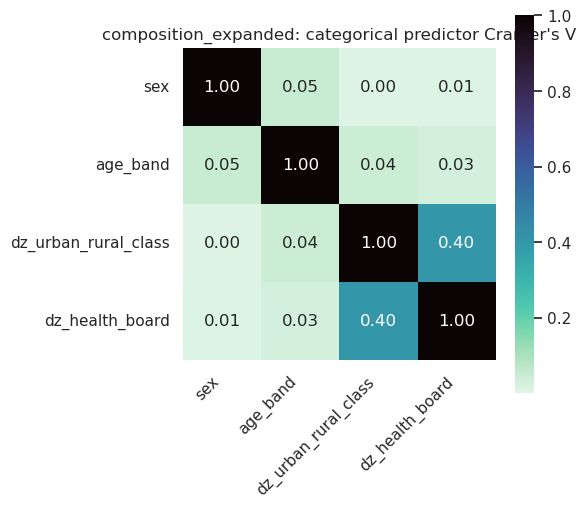

In [7]:
MODEL_TO_PLOT = "composition_expanded"
outputs = all_outputs[MODEL_TO_PLOT]

plot_heatmap(
    outputs["spearman"],
    f"{MODEL_TO_PLOT}: numeric predictor Spearman correlations",
    center=0,
    cmap="vlag",
)

if len(outputs["categorical_cols"]) >= 2:
    plot_heatmap(
        outputs["cat_cat"],
        f"{MODEL_TO_PLOT}: categorical predictor Cramer's V",
        center=None,
        cmap="mako_r",
    )

## Compare Primary vs Expanded Inputs

This compact view is useful for spotting whether expanded datazone context variables are strongly coupled to window context variables or existing composition/mixing predictors.

In [8]:
summary_rows = []
for model_name, outputs in all_outputs.items():
    numeric_top = outputs["numeric_top"]
    cat_num = outputs["cat_num"]
    y_num = outputs["candidate_numeric"]
    y_cat = outputs["candidate_categorical"]

    summary_rows.append(
        {
            "model": model_name,
            "max_abs_numeric_corr": numeric_top["abs_correlation"].max() if not numeric_top.empty else np.nan,
            "strong_numeric_pairs_abs_ge_0_70": int((numeric_top["abs_correlation"] >= 0.70).sum()) if not numeric_top.empty else 0,
            "max_eta_squared": cat_num["eta_squared"].max() if not cat_num.empty else np.nan,
            "max_abs_candidate_numeric_corr": y_num["abs_candidate_correlation"].max() if not y_num.empty else np.nan,
            "max_candidate_categorical_cramers_v": y_cat["cramers_v_with_candidate"].max() if not y_cat.empty else np.nan,
        }
    )

association_overview = pd.DataFrame(summary_rows)
association_overview.to_csv(CORR_DIR / "association_overview.csv", index=False)
association_overview

,model,max_abs_numeric_corr,strong_numeric_pairs_abs_ge_0_70,max_eta_squared,max_abs_candidate_numeric_corr,max_candidate_categorical_cramers_v
0,composition_primary,0.659853,0,0.049069,0.140884,0.036770
1,composition_expanded,0.956803,1,0.049057,0.140834,0.036761
2,mixing_null_primary,0.869817,1,NaN,0.059164,NaN
3,mixing_null_expanded,0.980733,4,NaN,0.059164,NaN
4,mixing_observed_primary,0.896988,3,NaN,0.294216,NaN
5,mixing_observed_expanded,0.981206,6,NaN,0.294216,NaN


## Optional: Inspect One Predictor Pair

Use this section when a high-correlation pair needs a sanity check beyond the summary table.

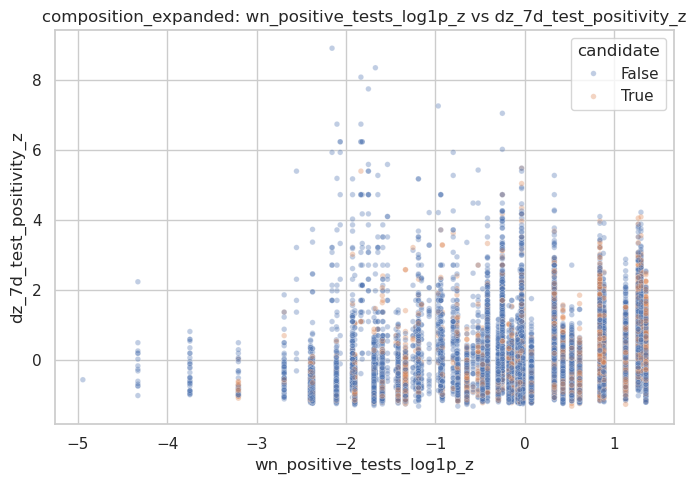

In [11]:
MODEL_FOR_PAIR = "composition_expanded"
X = "wn_positive_tests_log1p_z"
Y = "dz_7d_test_positivity_z"

frame = analysis_frames[MODEL_FOR_PAIR]
if X in frame.columns and Y in frame.columns:
    plt.figure(figsize=(7, 5))
    sns.scatterplot(
        data=frame.sample(min(len(frame), 20_000), random_state=RANDOM_SEED),
        x=X,
        y=Y,
        hue="candidate",
        alpha=0.35,
        s=16,
    )
    plt.title(f"{MODEL_FOR_PAIR}: {X} vs {Y}")
    plt.tight_layout()
    plt.show()
else:
    print(f"Columns not found in {MODEL_FOR_PAIR}: {X}, {Y}")

## Notes for Interpretation

High association among predictors is not automatically a problem, but it changes what the Bayesian coefficients mean. If two predictors are strongly linked, each coefficient is conditional on the other being held fixed, which may be a narrow or unstable comparison. For the model-building workflow, the most important checks are:

- `abs(Spearman) >= 0.7` among numeric predictors
- strong links between window surveillance variables and datazone context variables
- strong Cramer's V among composition categories, especially geography-like variables
- predictors that are strongly associated with `candidate` before adjustment